In [1]:
from wjp_judicial_independence.config import PATH_DATA_RAW, PATH_DATA_INTERIM
from wjp_judicial_independence.preprocessing import load_events
from wjp_judicial_independence.classifier import classify_events
from wjp_judicial_independence.plot import plot_events_by_pillar
import polars as pl
import openai

# Preprocesamiento
Cargamos los archivos JSON de noticias por país y extraemos eventos individuales. Cada archivo contiene resúmenes de noticias organizados   por pilar del WJP y su impacto (e.g. Very Positive, Negative). Dado que estos resúmenes agrupan múltiples eventos, aplicamos una estrategia de chunking por párrafo (`\n`) y filtramos únicamente los párrafos que corresponden a eventos concretos (aquellos que comienzan con `* **`), descartando títulos, conclusiones y texto de relleno.

In [4]:
df = load_events(PATH_DATA_RAW)
df

country,pillar,impact,event
str,str,str,str
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …"
…,…,…,…
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Inadequate Healthcare:** T…"
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Lack of Effective Rehabili…"
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Attacks on Freedom of Expr…"


# Estrategia 1: Clasificación con modelos de embeddings + similitud semántica

  Para clasificar si un evento es relevante a **independencia judicial**, utilizamos similitud semántica. Cada evento se codifica como un vector denso $\mathbf{e} \in \mathbb{R}^{N}$ usando el modelo `all-mpnet-base-v2` de la librería sentence-transformers.      
  Definimos tres categorías de referencia relacionadas a independencia judicial basándonos en el documento adjunto de resumen del marco conceptual de independencia judicial de WJP:                                                                             
  - **Cumplimiento de decisiones judiciales:** cobertura sobre si el ejecutivo acata o desafía fallos judiciales políticamente sensibles.
  - **Corrupción judicial:** alegaciones, investigaciones o procesamientos de actores judiciales por soborno o abuso de cargo.
  - **Nombramientos judiciales y confianza pública:** transparencia en nombramientos y percepción ciudadana sobre la imparcialidad del sistema   judicial.

Cada categoría se describe con un texto de referencia que también se codifica como embedding $\mathbf{r} \in \mathbb{R}^{N}$. Luego  calculamos la similitud coseno entre cada evento y cada referencia:
                                                                                                                                             $$\text{score}(e, r) = \frac{\mathbf{e} \cdot \mathbf{r}}{|\mathbf{e}| |\mathbf{r}|}$$                                                      
  Un evento se marca como relevante (`is_judicial_independence = True`) si supera el umbral de similitud en al menos una de las tres categorías. 

**NOTA:** Este modelamiento fue una decisión en desarrollo, el _deber ser_ es probar distintos modelamientos. Por ejemplo, probar si solo teniendo 1 definición completa (en lugar de 3, con cada definición un threshold) da mejores resultados. No se probó por temas de tiempo, pues se dio prioridad también a otro modelamiento más creativo (Modelo 2)

In [6]:
EMBEDDING_MODEL_NAME = 'all-mpnet-base-v2' # si encontramos algún modelo más apto, simplemente lo cambiamos para que nos de mejores resultados

REFERENCES = {
    "compliance_with_judicial_decisions": """
        Whether politically sensitive rulings are implemented by the executive 
        or ignored, undermined or defied. News coverage documents executive 
        statements, policy reversals, or civil society responses to non-compliance 
        with court rulings.
    """,
    "judicial_corruption_scandals": """
        Allegations, investigations or prosecutions of judicial actors for bribery, 
        influence trading or abuse of office. Scandals involving judges, frequency 
        and framing of corruption cases and their institutional consequences.
    """,
    "judicial_appointments_and_public_trust": """
        Transparency and contestation around judicial appointments, and public 
        sentiment about judicial fairness and independence. Naming of judges, 
        political salience of appointments, public confidence and trust in courts,
        opinion pieces and editorial framing of judicial impartiality.
    """
}

THRESHOLDS = {
    "compliance_with_judicial_decisions": 0.5,
    "judicial_corruption_scandals": 0.5,
    "judicial_appointments_and_public_trust": 0.5
}

df_ji_with_embeddings = classify_events(df, "embeddings", model_name=EMBEDDING_MODEL_NAME, references=REFERENCES, thresholds=THRESHOLDS)
df_ji_with_embeddings.write_parquet(PATH_DATA_INTERIM/"module1/df_embeddings_strategy_judicial_independence.parquet") # guardar los resultados
df_ji_with_embeddings

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


country,pillar,impact,event,embedding,score_compliance_with_judicial_decisions,score_judicial_corruption_scandals,score_judicial_appointments_and_public_trust,is_judicial_independence
str,str,str,str,"array[f32, 768]",f32,f32,f32,bool
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…","[0.055642, 0.030804, … 0.019532]",0.502467,0.640566,0.535574,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…","[0.031283, 0.048275, … 0.021095]",0.428725,0.409757,0.471078,false
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…","[0.043142, 0.027225, … 0.021994]",0.575841,0.648641,0.655584,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…","[-0.020327, 0.069766, … 0.025625]",0.375987,0.548091,0.33353,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …","[0.011043, 0.065096, … 0.000256]",0.410103,0.424873,0.397865,false
…,…,…,…,…,…,…,…,…
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Inadequate Healthcare:** T…","[0.018282, 0.117477, … 0.028484]",0.231547,0.298709,0.23002,false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Lack of Effective Rehabili…","[0.061463, 0.121285, … 0.028841]",0.24608,0.370001,0.242094,false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Attacks on Freedom of Expr…","[0.025805, 0.072293, … -0.018072]",0.427411,0.40629,0.350115,false


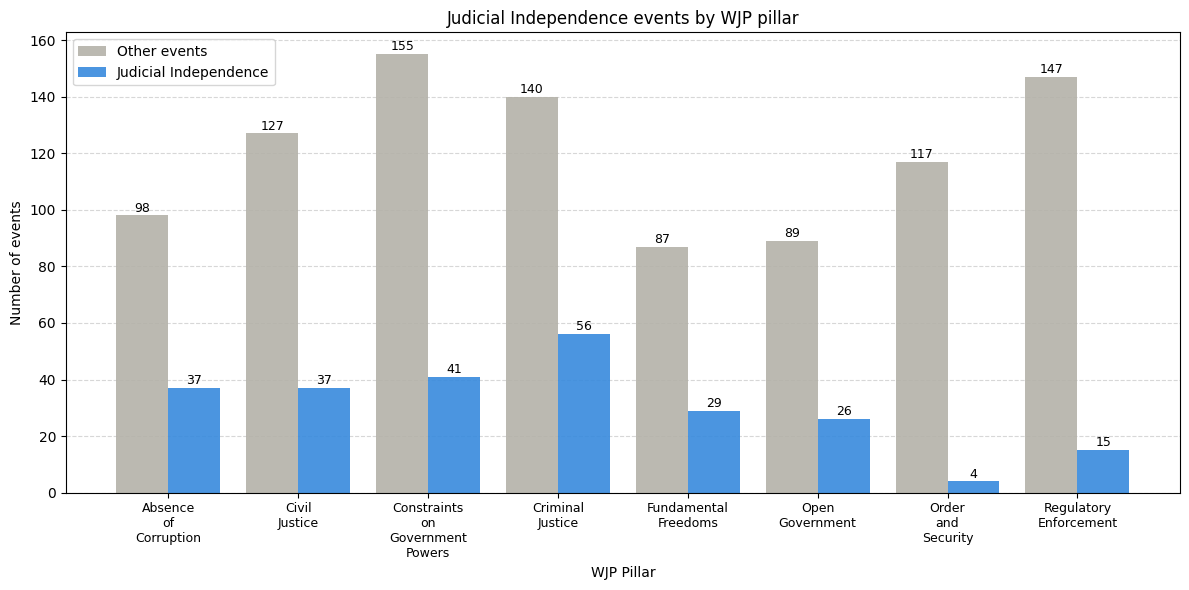

In [7]:
plot_events_by_pillar(df_ji_with_embeddings)

# Estrategia 2: Clasificación basada en LLMs
En lugar de hacerlo directo con el truco de crear embeddings de referencias, le pedimos a un modelo de lenguaje grande, como Qwen, Llama, o modelos de pago como gpt, opus, etc. que de un score de 0 o 1 para `is_judicial_independence`.

In [8]:
SYSTEM_PROMPT = """You are an expert classifier for de facto judicial independence events.
Classify whether a news event is related to judicial independence (1) or not (0).

Classify as 1 if the event involves:
- Courts or judges acting independently from political pressure
- Executive compliance or non-compliance with judicial decisions
- Judicial corruption scandals (bribery, influence trading by judicial actors)
- Judicial appointments, transparency, contestation, or politicization
- Public trust/distrust in judicial fairness and impartiality
- Political attacks on or interference with judicial institutions
- Judicial reform strengthening or weakening court independence
- Separation of powers conflicts involving the judiciary
- Prosecutors investigating government officials independently
- Constitutional courts striking down government actions

Classify as 0 if the event is about:
- General crime (drug busts, murders, robberies) not involving judicial independence
- Police operations, arrests, public safety
- Regulatory enforcement without court independence themes
- Elections, voter turnout without judicial involvement
- General government policy, infrastructure, education, healthcare

CRITICAL: Not every justice-related event is about judicial independence. A drug arrest is NOT
judicial independence. A court overturning a government decree IS.

Respond with ONLY 1 or 0. Nothing else."""

USER_MSG_TEMPLATE = (
    "Country: {country} | Pillar: {pillar}\n\n"
    "Event:\n{event}\n\nClassification (1 or 0):"
)

### Modelos gratuitos locales

In [8]:
LLM_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct" # modelos de la librería transformers, gratuitos
df_ji_with_llm = classify_events(df, "llm", model_name=LLM_MODEL_NAME, system_prompt=SYSTEM_PROMPT, user_msg_template=USER_MSG_TEMPLATE)
df_ji_with_llm.write_parquet(PATH_DATA_INTERIM/"module1/df_llm_strategy_judicial_independence.parquet") # guardar los resultados
df_ji_with_llm

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/1205 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/home/danielaguirre/Projects/wjp-judicial-independence/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1205/1205 [04:17<00:00,  4.67it/s]


country,pillar,impact,event,is_judicial_independence
str,str,str,str,bool
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…",false
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …",false
…,…,…,…,…
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Inadequate Healthcare:** T…",false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Lack of Effective Rehabili…",false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Attacks on Freedom of Expr…",false


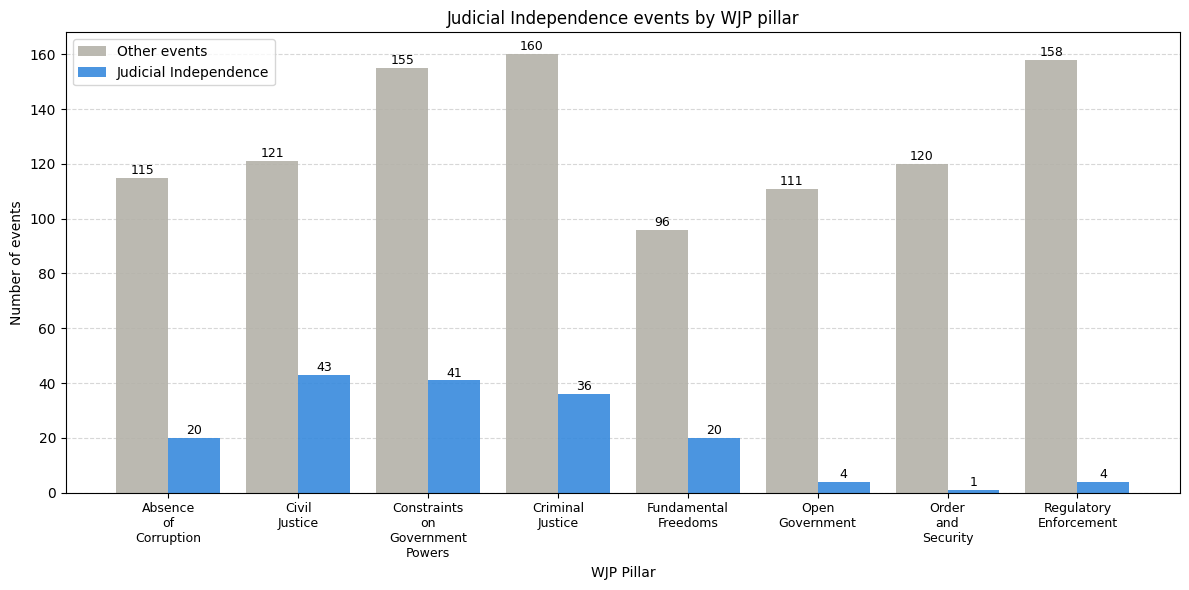

In [9]:
plot_events_by_pillar(df_ji_with_llm)

### Modelos de pago (Ejemplo con modelo de OpenAI)

In [9]:
API_KEY = "<INTRODUZCA SU API KEY AQUÍ>" # tenía creditos en ChatGPT por lo que utilicé el modelo gpt-4o de OpenAI
client = openai.OpenAI(api_key=API_KEY)
LLM_MODEL_NAME = "gpt-4o-mini"
df_ji_with_llm_api = classify_events(df, "llm-api", client=client, model_name=LLM_MODEL_NAME, system_prompt=SYSTEM_PROMPT, user_msg_template=USER_MSG_TEMPLATE)
df_ji_with_llm_api.write_parquet(PATH_DATA_INTERIM/"module1/df_llm-api_strategy_judicial_independence.parquet") # guardar los resultados
df_ji_with_llm_api

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1205/1205 [14:11<00:00,  1.42it/s]


country,pillar,impact,event,is_judicial_independence
str,str,str,str,bool
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…",true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…",false
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …",false
…,…,…,…,…
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Inadequate Healthcare:** T…",false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Lack of Effective Rehabili…",false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Attacks on Freedom of Expr…",true


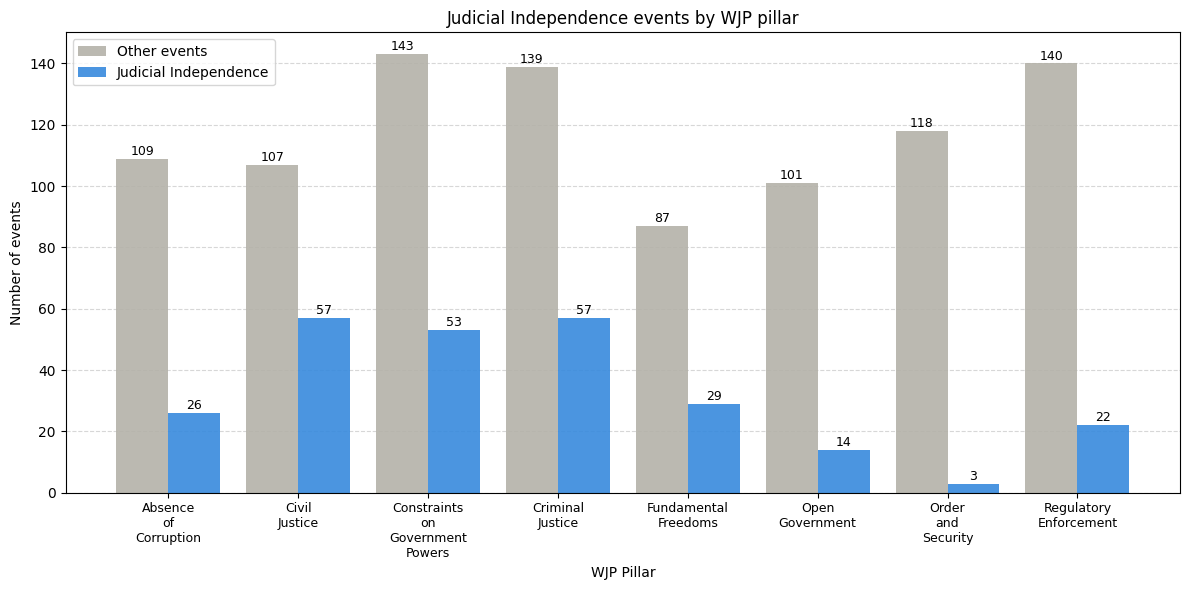

In [10]:
plot_events_by_pillar(df_ji_with_llm_api)